In [30]:
import pandas as pd
from sklearn import model_selection
from sklearn import tree
import matplotlib.pyplot as plt
from feature_engine import discretisation, encoding
from sklearn import linear_model
from sklearn import naive_bayes
from sklearn import ensemble
from sklearn import pipeline
import mlflow
from sklearn import metrics

In [31]:
df = pd.read_csv("data/abt_churn.csv")
df.head(5)

,dtRef,idUsuario,qtdeTransacoes,qtdeDias,mediaTransacoesDias,saldoPontos,qtdePontosPos,qtdePontosNeg,qtdeDiasUltimaTransacao,qtdeDiasPrimeiraTransacao,...,saldoPontosD28,qtdePontosPosD28,qtdePontosNegD28,propAvgQtdeTransacoes,propAvgQtdeDias,propAvgMediaTransacoesDias,propAvgSaldoPontos,propAvgQtdePontosPos,propAvgQtdePontosNeg,flagChurn
0,2024-06-01,000ff655-fa9f-4baa-a108-47f581ec52a1,266,27,9.851852,635,2635,-2000,1.0,89.0,...,151,151,0,3.889781,3.278281,2.135602,1.516314,4.101926,8.944444,1
1,2024-10-01,000ff655-fa9f-4baa-a108-47f581ec52a1,268,28,9.571429,686,2686,-2000,4.0,211.0,...,51,51,0,3.309865,2.567615,2.328737,1.288278,2.920954,5.167037,1
2,2024-04-01,000ff655-fa9f-4baa-a108-47f581ec52a1,188,11,17.090909,275,1275,-1000,3.0,28.0,...,275,1275,-1000,3.805468,1.820201,3.739048,0.798622,2.634551,7.162791,0
3,2024-05-01,000ff655-fa9f-4baa-a108-47f581ec52a1,262,24,10.916667,484,2484,-2000,2.0,58.0,...,107,1107,-1000,4.246216,3.255244,2.322640,1.275749,4.275765,9.922414,0
4,2024-08-01,001749bd-37b5-4b1e-8111-f9fbba90f530,1,1,1.000000,50,50,0,21.0,21.0,...,50,50,0,0.013317,0.103973,0.236635,0.104533,0.063302,0.000000,1


**Sample**
-

**Out of time**

In [32]:
oot = df[df['dtRef'] == df['dtRef'].max()].copy()
oot.head()

,dtRef,idUsuario,qtdeTransacoes,qtdeDias,mediaTransacoesDias,saldoPontos,qtdePontosPos,qtdePontosNeg,qtdeDiasUltimaTransacao,qtdeDiasPrimeiraTransacao,...,saldoPontosD28,qtdePontosPosD28,qtdePontosNegD28,propAvgQtdeTransacoes,propAvgQtdeDias,propAvgMediaTransacoesDias,propAvgSaldoPontos,propAvgQtdePontosPos,propAvgQtdePontosNeg,flagChurn
8,2025-04-01,0033b737-8235-4c0f-9801-dc4ca185af00,445,25,17.800000,2066,2066,0,6.0,197.0,...,976,976,0,5.463477,2.123061,4.501847,3.989389,2.191048,0.000000,1
21,2025-04-01,0122142b-464c-414a-9aad-e901f492a1a3,23,4,5.750000,121,121,0,7.0,81.0,...,2,2,0,0.282382,0.339690,1.454248,0.233648,0.128324,0.000000,1
53,2025-04-01,0287cd05-1efe-4ad9-b235-ea17e5f8ef9c,303,45,6.733333,3248,3498,-250,1.0,351.0,...,615,615,0,3.720076,3.821510,1.702946,6.271798,3.709722,0.588161,0
61,2025-04-01,02bfd4d9-4dd6-44e5-88b8-2cc08caf3267,338,89,3.797753,3643,7143,-3500,4.0,333.0,...,265,265,0,4.149787,7.558098,0.960500,7.034532,7.575342,8.234250,0
74,2025-04-01,02ebaed5-c07a-4bdd-bb7b-5334d5b25b39,245,51,4.803922,3813,3813,0,18.0,246.0,...,50,50,0,3.007982,4.331045,1.214973,7.362797,4.043788,0.000000,1


In [33]:
df_train = df[df['dtRef'] < df['dtRef'].max()].copy()
print(df_train.shape)
df_train.head()

(5193, 43)


,dtRef,idUsuario,qtdeTransacoes,qtdeDias,mediaTransacoesDias,saldoPontos,qtdePontosPos,qtdePontosNeg,qtdeDiasUltimaTransacao,qtdeDiasPrimeiraTransacao,...,saldoPontosD28,qtdePontosPosD28,qtdePontosNegD28,propAvgQtdeTransacoes,propAvgQtdeDias,propAvgMediaTransacoesDias,propAvgSaldoPontos,propAvgQtdePontosPos,propAvgQtdePontosNeg,flagChurn
0,2024-06-01,000ff655-fa9f-4baa-a108-47f581ec52a1,266,27,9.851852,635,2635,-2000,1.0,89.0,...,151,151,0,3.889781,3.278281,2.135602,1.516314,4.101926,8.944444,1
1,2024-10-01,000ff655-fa9f-4baa-a108-47f581ec52a1,268,28,9.571429,686,2686,-2000,4.0,211.0,...,51,51,0,3.309865,2.567615,2.328737,1.288278,2.920954,5.167037,1
2,2024-04-01,000ff655-fa9f-4baa-a108-47f581ec52a1,188,11,17.090909,275,1275,-1000,3.0,28.0,...,275,1275,-1000,3.805468,1.820201,3.739048,0.798622,2.634551,7.162791,0
3,2024-05-01,000ff655-fa9f-4baa-a108-47f581ec52a1,262,24,10.916667,484,2484,-2000,2.0,58.0,...,107,1107,-1000,4.246216,3.255244,2.322640,1.275749,4.275765,9.922414,0
4,2024-08-01,001749bd-37b5-4b1e-8111-f9fbba90f530,1,1,1.000000,50,50,0,21.0,21.0,...,50,50,0,0.013317,0.103973,0.236635,0.104533,0.063302,0.000000,1


In [34]:
features = df_train.columns[2:-1]
target = 'flagChurn'

X, y = df[features], df[target]
X_train, X_test, y_train, y_test = model_selection.train_test_split(X, y, random_state=42, test_size=0.2, stratify=y)

In [35]:
print(X_train.shape[0])
print(y_train.shape[0])

4396
4396


Estratificação

In [36]:
print('Taxa da variável resposta Geral: ', y.mean())
print('Taxa da variável resposta Treino: ', y_train.mean())
print('Taxa da variável resposta Teste: ', y_test.mean())

Taxa da variável resposta Geral:  0.4708879184861718
Taxa da variável resposta Treino:  0.4708826205641492
Taxa da variável resposta Teste:  0.4709090909090909


**Explore**
-

In [37]:
X_train.isna().sum().sort_values(ascending=False)

qtdeTransacoes                0
qtdeDias                      0
mediaTransacoesDias           0
saldoPontos                   0
qtdePontosPos                 0
qtdePontosNeg                 0
qtdeDiasUltimaTransacao       0
qtdeDiasPrimeiraTransacao     0
qtdSkuDistintos               0
qtdeChatMessage               0
qtdePresença                  0
qtdeTrocaStreamElements       0
qtdeChurn                     0
qtdePonei                     0
qtdeAirflowLover              0
qtdePresencaStreak            0
qtdeDailyLoot                 0
qtdeRLover                    0
qtdeVendaItemRPG              0
qtdeTransacoesD7              0
qtdeDiasD7                    0
saldoPontosD7                 0
qtdePontosPosD7               0
qtdePontosNegD7               0
qtdeTransacoesD14             0
qtdeDiasD14                   0
saldoPontosD14                0
qtdePontosPosD14              0
qtdePontosNegD14              0
qtdeTransacoesD28             0
qtdeDiasD28                   0
saldoPon

In [38]:
df_analysis = X_train.copy()
df_analysis[target] = y_train.copy()
df_analysis.head(5)

,qtdeTransacoes,qtdeDias,mediaTransacoesDias,saldoPontos,qtdePontosPos,qtdePontosNeg,qtdeDiasUltimaTransacao,qtdeDiasPrimeiraTransacao,qtdSkuDistintos,qtdeChatMessage,...,saldoPontosD28,qtdePontosPosD28,qtdePontosNegD28,propAvgQtdeTransacoes,propAvgQtdeDias,propAvgMediaTransacoesDias,propAvgSaldoPontos,propAvgQtdePontosPos,propAvgQtdePontosNeg,flagChurn
2448,36,4,9.000000,183,183,0,12.0,79.0,2,33,...,104,104,0,0.421339,0.335471,2.253441,0.322876,0.181456,0.000000,0
2836,16,9,1.777778,310,310,0,2.0,29.0,2,10,...,307,307,0,0.530737,2.426299,0.382917,1.203134,1.055744,0.000000,0
966,343,46,7.456522,1022,3522,-2500,1.0,82.0,8,272,...,-1218,1282,-2500,4.236133,4.218224,1.814178,1.919272,3.830081,6.458796,0
1889,42,3,14.000000,42,42,0,1.0,3.0,1,42,...,42,42,0,1.393184,0.808766,3.015470,0.163005,0.143036,0.000000,0
416,169,89,1.898876,4912,7162,-2250,11.0,400.0,9,51,...,153,153,0,2.074894,7.558098,0.480250,9.484936,7.595492,5.293446,0


In [39]:
summarie = df_analysis.groupby(by=target).agg(['mean',
                                               'median']).T
summarie

flagChurn                             0          1
qtdeTransacoes       mean    348.006879  53.644928
                     median   54.000000   9.000000
qtdeDias             mean     31.826741   9.429469
                     median   14.000000   3.000000
mediaTransacoesDias  mean      6.271525   3.886673
...                                 ...        ...
propAvgSaldoPontos   median    1.317443   0.316423
propAvgQtdePontosPos mean      4.027320   0.839738
                     median    1.091285   0.208901
propAvgQtdePontosNeg mean      5.275117   0.614755
                     median    0.000000   0.000000

[80 rows x 2 columns]

In [40]:
summarie['diff_abs'] = summarie[0] - summarie[1]
summarie['diff_rel'] = summarie[0] / summarie[1]
summarie.sort_values(by='diff_rel', ascending=False)

,flagChurn,0,1,diff_abs,diff_rel
qtdeDiasD7,median,1.0,0.0,1.0,inf
qtdeTransacoesD7,median,3.0,0.0,3.0,inf
saldoPontosD7,median,50.0,0.0,50.0,inf
qtdePontosPosD7,median,52.0,0.0,52.0,inf
qtdePontosPosD14,median,106.0,1.0,105.0,106.0
...,...,...,...,...,...
qtdeVendaItemRPG,median,0.0,0.0,0.0,NaN
qtdePontosNegD7,median,0.0,0.0,0.0,NaN
qtdePontosNegD14,median,0.0,0.0,0.0,NaN
qtdePontosNegD28,median,0.0,0.0,0.0,NaN


2026/06/30 22:52:59 INFO mlflow.utils.autologging_utils: Created MLflow autologging run with ID '9228f31660bf438f9d099dab9251c825', which will track hyperparameters, performance metrics, model artifacts, and lineage information for the current sklearn workflow
2026/06/30 22:52:59 WARNING mlflow.utils.autologging_utils: MLflow autologging encountered a warning: "C:\Users\Gabri\PycharmProjects\churn_predict_project\.venv\Lib\site-packages\mlflow\types\utils.py:440: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling 

🏃 View run beautiful-donkey-301 at: http://127.0.0.1:5000/#/experiments/1/runs/9228f31660bf438f9d099dab9251c825
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1


[Text(0.5, 0.9166666666666666, 'qtdeDiasD14 <= 1.5\ngini = 0.498\nsamples = 4396\nvalue = [2326, 2070]\nclass = 0'),
 Text(0.24553571428571427, 0.75, 'propAvgQtdeDias <= 0.541\ngini = 0.439\nsamples = 2559\nvalue = [834.0, 1725.0]\nclass = 1'),
 Text(0.37276785714285715, 0.8333333333333333, 'True  '),
 Text(0.13392857142857142, 0.5833333333333334, 'qtdeDiasUltimaTransacao <= 10.5\ngini = 0.359\nsamples = 1426\nvalue = [335, 1091]\nclass = 1'),
 Text(0.07142857142857142, 0.4166666666666667, 'qtdeTransacoesD7 <= 9.5\ngini = 0.446\nsamples = 471\nvalue = [158, 313]\nclass = 1'),
 Text(0.03571428571428571, 0.25, 'propAvgQtdeTransacoes <= 0.013\ngini = 0.436\nsamples = 454\nvalue = [146, 308]\nclass = 1'),
 Text(0.017857142857142856, 0.08333333333333333, 'gini = 0.317\nsamples = 86\nvalue = [17, 69]\nclass = 1'),
 Text(0.05357142857142857, 0.08333333333333333, 'gini = 0.455\nsamples = 368\nvalue = [129.0, 239.0]\nclass = 1'),
 Text(0.10714285714285714, 0.25, 'qtdeDiasUltimaTransacao <= 4.5\

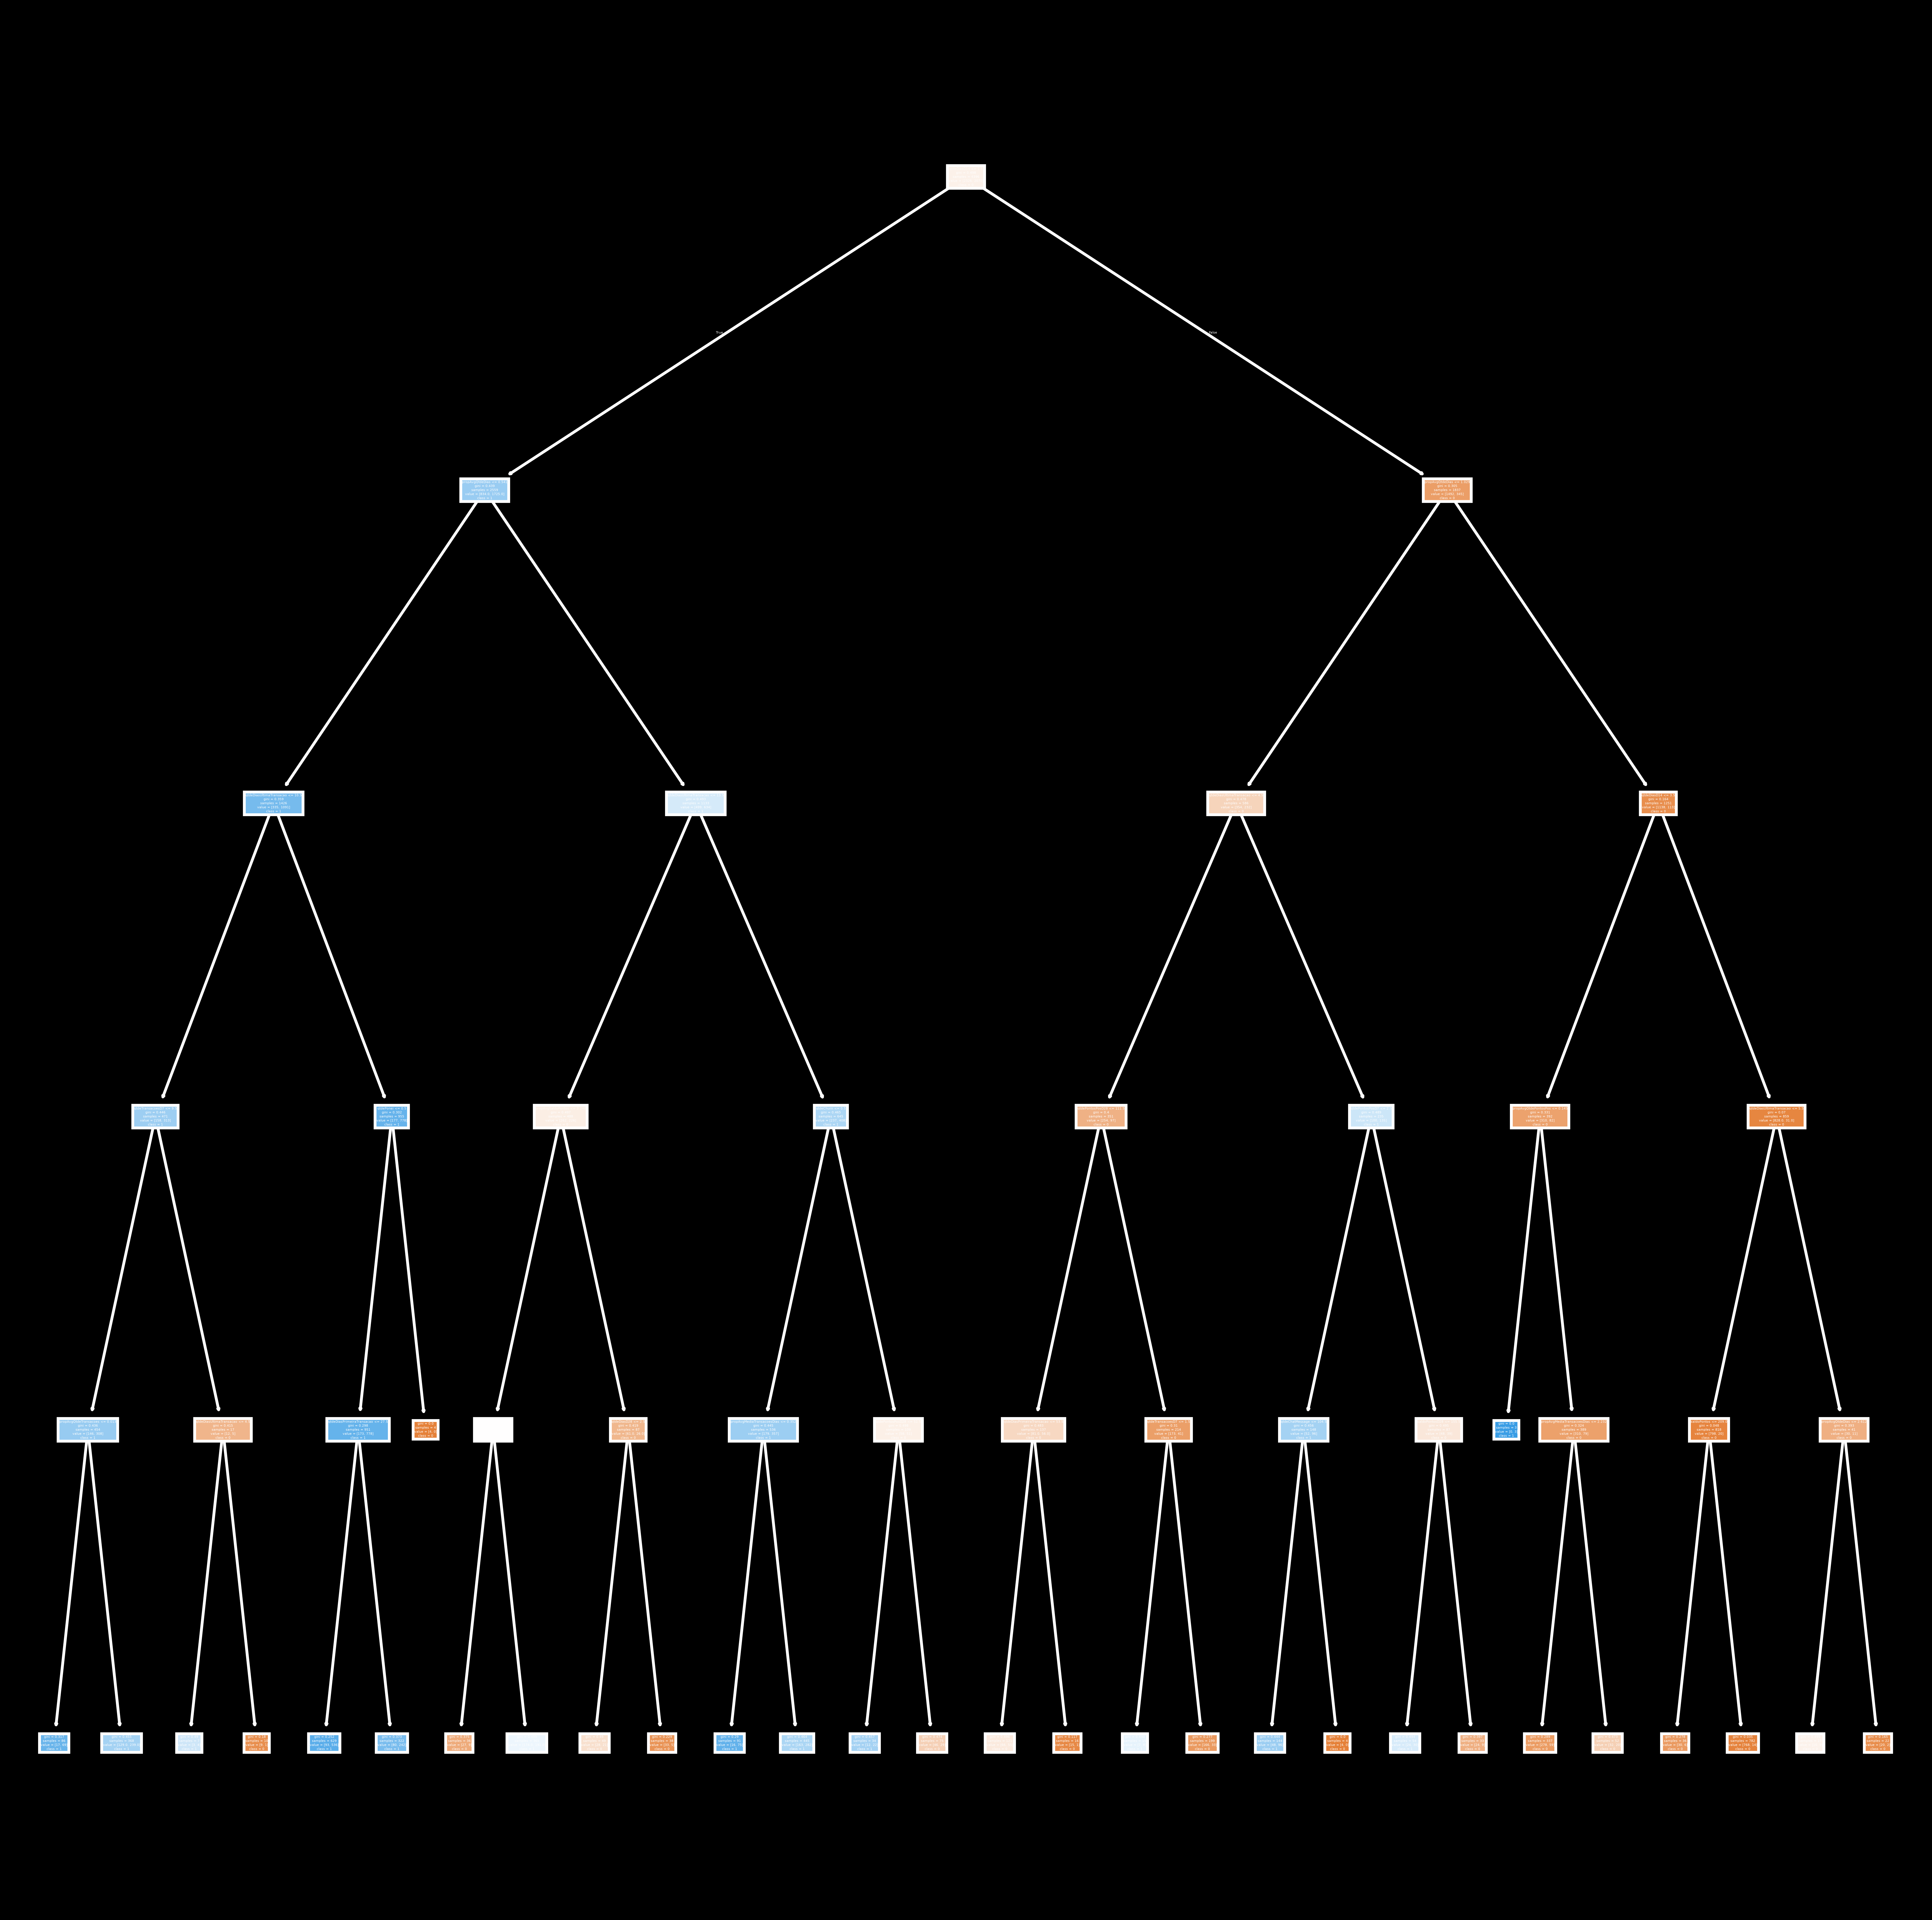

In [56]:
treed5 = tree.DecisionTreeClassifier(random_state=42, max_depth=5)
treed5.fit(X_train, y_train)
plt.figure(dpi=700, figsize=(12, 12))
tree.plot_tree(treed5, feature_names=X_train.columns, filled=True, class_names=[str(i) for i in treed5.classes_])

In [43]:
full_tree = tree.DecisionTreeClassifier(random_state=42)
full_tree.fit(X_train, y_train)
feature_importance = pd.Series(full_tree.feature_importances_, index=X_train.columns).sort_values(
    ascending=False).reset_index()

In [52]:
feature_importance['cum'] = feature_importance[0].cumsum()
feature_importance

,index,0,acumulada,cum
0,qtdeDiasD14,0.250897,0.250897,0.250897
1,propAvgQtdeDias,0.102146,0.353043,0.353043
2,qtdeDiasPrimeiraTransacao,0.076812,0.429855,0.429855
3,qtdeDiasUltimaTransacao,0.074065,0.503920,0.503920
4,propAvgQtdeTransacoes,0.052112,0.556032,0.556032
5,propAvgMediaTransacoesDias,0.050794,0.606826,0.606826
6,propAvgSaldoPontos,0.046586,0.653412,0.653412
7,propAvgQtdePontosPos,0.028407,0.681819,0.681819
8,mediaTransacoesDias,0.027758,0.709578,0.709578
9,qtdeChatMessage,0.026437,0.736015,0.736015


**Modify**
-

In [53]:
best_features = feature_importance[feature_importance.cum < 0.96]['index'].tolist()

Discretização

In [46]:
tree_discretization = discretisation.DecisionTreeDiscretiser(variables=best_features, regression=False, cv=3,bin_output='bin_number')

One hot

In [47]:
onehot = encoding.OneHotEncoder(variables=best_features, ignore_format=True)

**Model + Tunning**
-

In [48]:
#model = linear_model.LogisticRegression(random_state=42, C=np.inf, max_iter=10000)

#model = naive_bayes.BernoulliNB()

model = ensemble.RandomForestClassifier(random_state=42,n_jobs=-1)

# model = ensemble.AdaBoostClassifier(random_state=42,learning_rate=0.1,n_estimators=500)

In [ ]:
params ={
    'min_samples_leaf':[15, 20, 25, 30, 50],
    'n_estimators': [100, 200, 500, 1000],
    'criterion':['entropy',"log_loss","gini"]
}

grid = model_selection.GridSearchCV(model,
                                    param_grid=params,
                                    cv=3,
                                    scoring='roc_auc',
                                    verbose=4
                                    )

model_pipeline = pipeline.Pipeline(steps=[('Discretize', tree_discretization),
                                          ('One Hot Encoding', onehot),
                                          ('Grid', grid)])

mlflow.set_tracking_uri("http://127.0.0.1:5000/")

mlflow.set_experiment(experiment_name="churn_exp")

with mlflow.start_run(run_name=model.__str__()):
    mlflow.sklearn.autolog()
    model_pipeline.fit(X_train[best_features], y_train)

    y_train_predict = model_pipeline.predict(X_train[best_features])
    y_train_proba = model_pipeline.predict_proba(X_train[best_features])[:, 1]
    acc_train = metrics.accuracy_score(y_train, y_train_predict)
    auc_train = metrics.roc_auc_score(y_train, y_train_proba)
    roc_train = metrics.roc_curve(y_train, y_train_proba)

    y_test_predict = model_pipeline.predict(X_test[best_features])
    y_test_proba = model_pipeline.predict_proba(X_test[best_features])[:, 1]
    acc_test = metrics.accuracy_score(y_test, y_test_predict)
    auc_test = metrics.roc_auc_score(y_test, y_test_proba)
    roc_test = metrics.roc_curve(y_test, y_test_proba)

    oot_predict = model_pipeline.predict(oot[best_features])
    oot_proba = model_pipeline.predict_proba(oot[best_features])[:, 1]
    acc_oot = metrics.accuracy_score(oot[target], oot_predict)
    auc_oot = metrics.roc_auc_score(oot[target], oot_proba)
    roc_oot = metrics.roc_curve(oot[target], oot_proba)

    mlflow.log_metrics(
        {
        "acc_train":acc_train,
         "auc_train"  : auc_train,
          "acc_test"  :acc_test,
            "auc_test":auc_test,
           "acc_oot" :acc_oot,
          "auc_oot" : auc_oot
        }
    )

In [50]:
print("Acurácia treino: ", acc_train)
print("AUC treino: ", auc_train)
print("Acurácia teste: ", acc_test)
print("AUC teste: ", auc_test)
print("Acurácia OOT: ", acc_oot)
print("AUC OOT: ", auc_oot)

Acurácia treino:  0.7586442220200182
AUC treino:  0.8413642669923278
Acurácia teste:  0.72
AUC teste:  0.8023855962000292
Acurácia OOT:  0.7920792079207921
AUC OOT:  0.8551416122004357


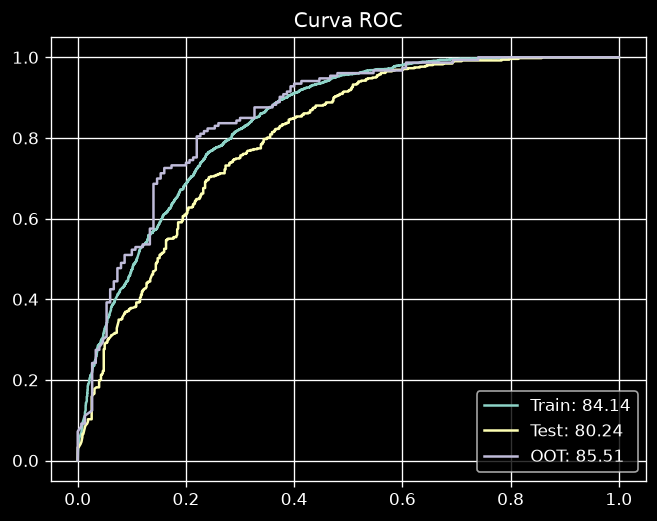

In [51]:
plt.figure(dpi=120)
plt.plot(roc_train[0], roc_train[1])
plt.plot(roc_test[0], roc_test[1])
plt.plot(roc_oot[0], roc_oot[1])
plt.grid(True)
plt.title("Curva ROC")
plt.legend([f'Train: {100*auc_train:.2f}',
            f'Test: {100*auc_test:.2f}',
            f'OOT: {100*auc_oot:.2f}'])